# Estudio de métodos tabulares para el aprendizaje por refuerzo en entornos discretos

## Introducción

## Preparación del entorno

In [1]:
# Librerías necesarias para el setup
import sys, os

### Ejecución en Colab

In [2]:
# Clonar el repositorio

In [3]:
# Añadir los directorio fuentes al path de Python

### Ejecución en local

In [4]:
# Añadir el directorio src al path para importar los módulos
src_path = os.path.abspath(os.path.join(os.getcwd(), 'src'))
if src_path not in sys.path:
    sys.path.append(src_path)
    
print(sys.path)

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv', '', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\.venv\\Lib\\site-packages', 'c:\\Users\\jorge\\EML_RL_LucasOrtiz\\entornos_complejos\\src']


### Importación de librerías y módulos

In [5]:
import gymnasium as gym

from agents import Agent
from learners import QLearning, SARSA, MCOnPolicy
from policies import EpsilonGreedyPolicy
from plotting import plot_rewards, plot_episode_lengths, plot_training_errors

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Entorno de Gymnasium

blablabla

In [7]:
env = gym.make('CliffWalking-v1') # is_slippery hace que haya una probabilidad de acabar en una casilla diferente a la que te has movido
state_size = env.observation_space.n
action_size = env.action_space.n

Pruebas varias:

In [8]:
alpha = 0.5 # Tasa de aprendizaje
gamma = 0.95 # Tasa de descuento
epsilon = 0.1 # Probabilidad de exploración en la política
discount_factor = 1 # Importancia el agente proporciona a futuras recompensas

policy = EpsilonGreedyPolicy(epsilon)
learner_qlearning = QLearning(state_size, action_size, alpha, gamma)
learner_sarsa = SARSA(state_size, action_size, alpha, gamma, policy)
leaner_mconpolicy = MCOnPolicy(state_size, action_size, discount_factor)

agent_qlearning = Agent(env, learner_qlearning, policy)
agent_sarsa = Agent(env, learner_sarsa, policy)
agent_mconpolicy = Agent(env, leaner_mconpolicy, policy)

In [9]:
num_episodes = 400
n_runs = 20
SEED = 123

In [ ]:
qtable_mconpolicy, rewards_mconpolicy, episode_lengths_mconpolicy, stats_mconpolicy = agent_mconpolicy.train(num_episodes, n_runs, SEED)

In [ ]:
qtable_qlearning, rewards_qlearning, episode_lengths_qlearning, stats_qlearning = agent_qlearning.train(num_episodes, n_runs, SEED)
qtable_sarsa, rewards_sarsa, episode_lengths_sarsa, stats_sarsa = agent_sarsa.train(num_episodes, n_runs, SEED)

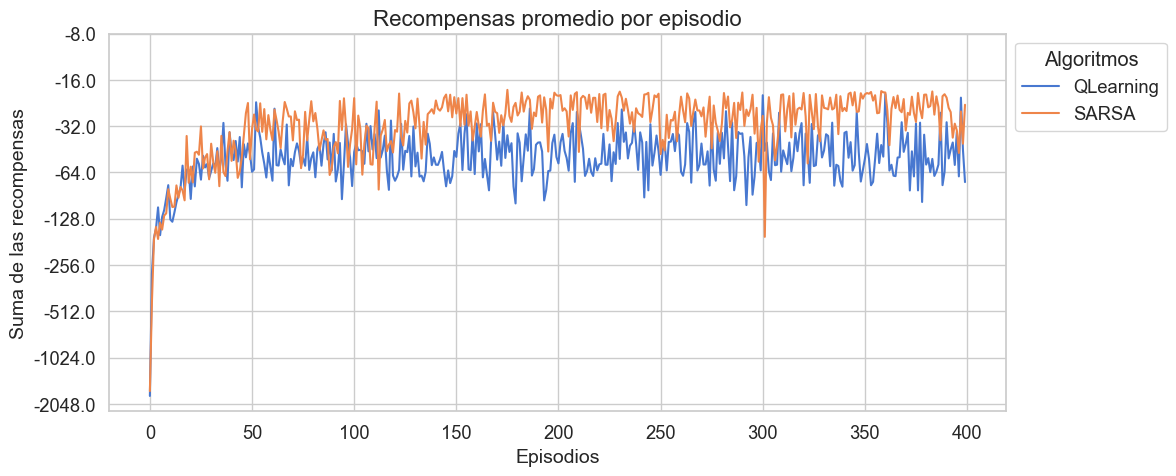

In [ ]:
plot_rewards([rewards_qlearning, rewards_sarsa], 
             legend_labels=[type(learner_qlearning).__name__, type(learner_sarsa).__name__], 
             log_scale=True)

Hagamos la media de los últimos valores de recompensa de cada algoritmo:

In [ ]:
print("qlearning:", rewards_qlearning[-50:].mean())
print("sarsa:", rewards_sarsa[-50:].mean())

qlearning: -52.480999999999995
sarsa: -25.383000000000003


Encaja a la perfección con lo que se ve en el libro de Sutton Barto (en [esta](https://bpb-us-e1.wpmucdn.com/sites.gatech.edu/dist/d/958/files/2022/02/SARSAvsQ.png) imagen).

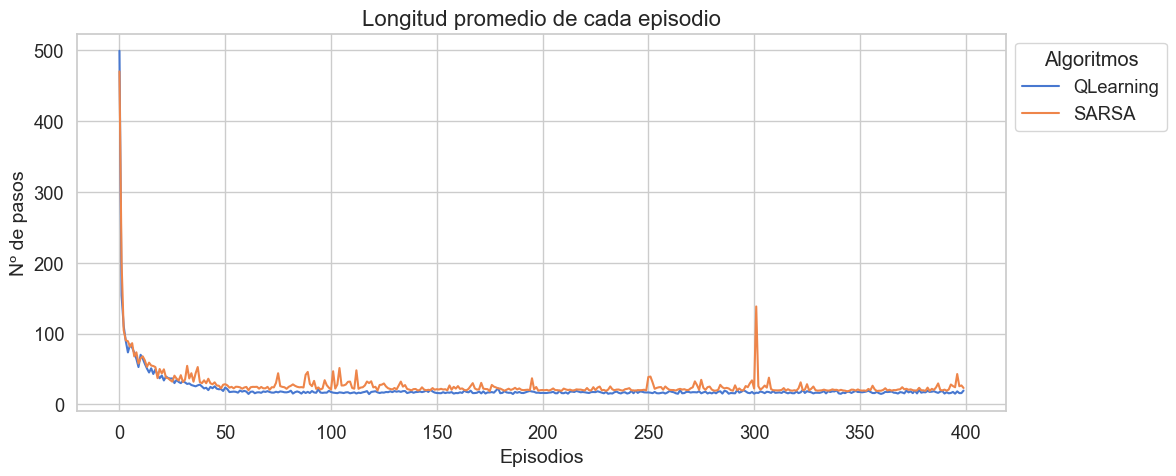

In [ ]:
plot_episode_lengths([episode_lengths_qlearning, episode_lengths_sarsa], 
                     legend_labels=[type(learner_qlearning).__name__, type(learner_sarsa).__name__], 
                     log_scale=False)

In [ ]:
def undo_cumsum(arr): # https://stackoverflow.com/a/38666977
    new_arr = list(arr)
    new_arr[1:] -= arr[:-1].copy() 
    return new_arr

In [ ]:
train_error_no_acum_qlearning = undo_cumsum(stats_qlearning['cum_training_error'])
train_error_no_acum_sarsa = undo_cumsum(stats_sarsa['cum_training_error'])

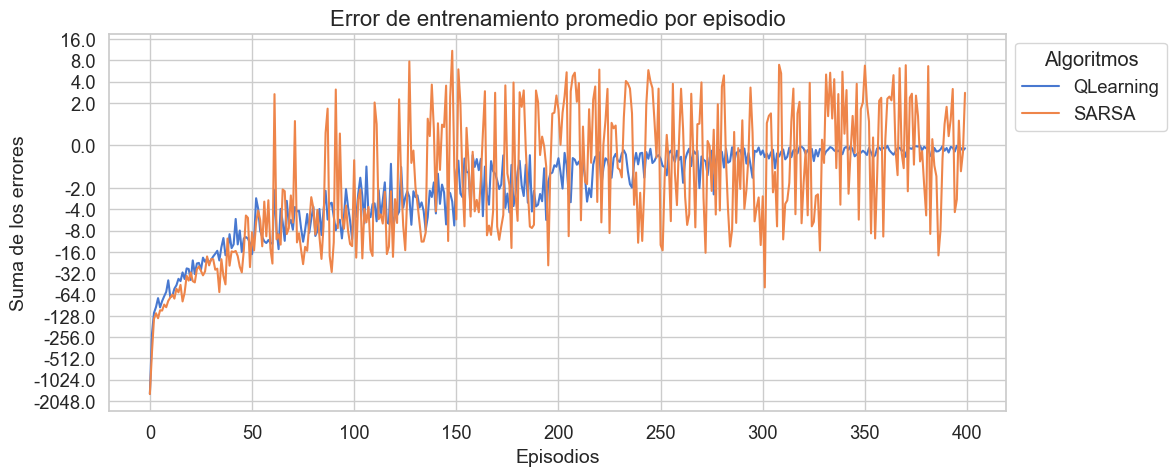

In [ ]:
plot_training_errors([train_error_no_acum_qlearning, train_error_no_acum_sarsa], 
                     legend_labels=[type(learner_qlearning).__name__, type(learner_sarsa).__name__], 
                     log_scale=True)

Es normal que en SARSA sean tan erráticos porque usamos una politica epsilon greedy, por lo que no siempre se selecciona la acción que maximiza la Q. Quizás habría que suavizar el gráfico con una media móvil, o quizás esta métrica no es muy interesante en el caso de sarsa y no merece la pena mostrarla, no lo tengo claro.

Otras gráficas que podrían ser interesantes: mostrar alguna medida de rendimiento (ej: las recompensas promedio o el error en el caso de diferencias temporales) en función del valor de alpha (tasa de aprendizaje). En diferencias temporales de n pasos, se pueden mostrar en la misma gráfica las curvas para varios valores de n, por ejemplo. En las diapositivas de clase y el libro de sutton barto puede haber alguna otra gráfica interesante.